Enter start Y coordinate (0-99): 2
Enter start X coordinate (0-99): 3
Enter goal Y coordinate (0-99): 98
Enter goal X coordinate (0-99): 75
step1: plotting initial grid. close the window to continue.


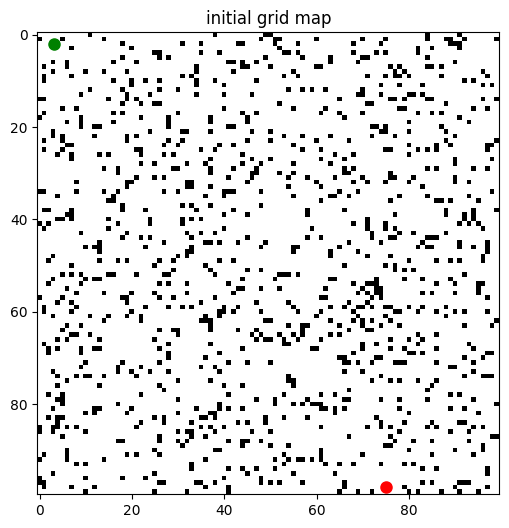

step2: running a* baseline. close the window to continue.
baseline a* time: 0.037786245346069336 seconds
baseline path length: 97


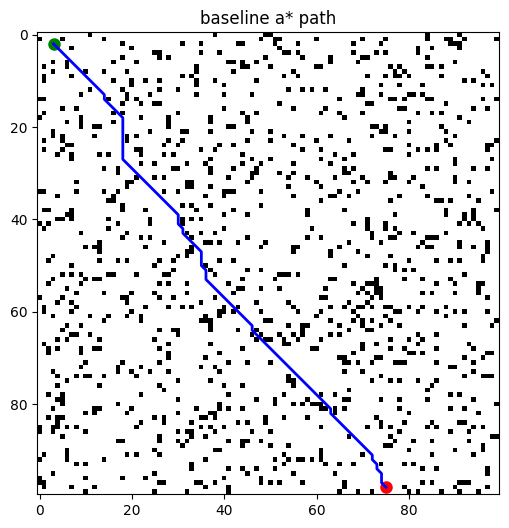

steps3&4: running ga with multiple hyperparameter configurations.
stopping early at generation 99 due to non improvement of fitness.

ga config: {'pop': 50, 'mut': 0.1, 'gen': 150, 'pat': 30, 'wp': 6}
execution time: 1.3524961471557617 seconds
best fitness achieved: 121.45216957349224
path length: 99


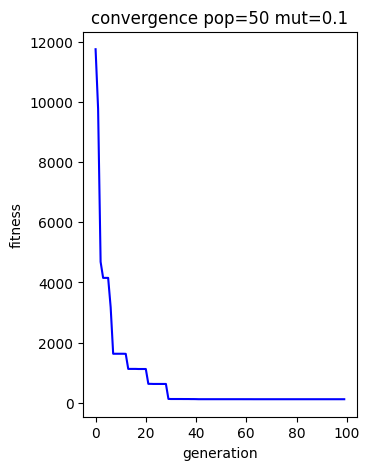

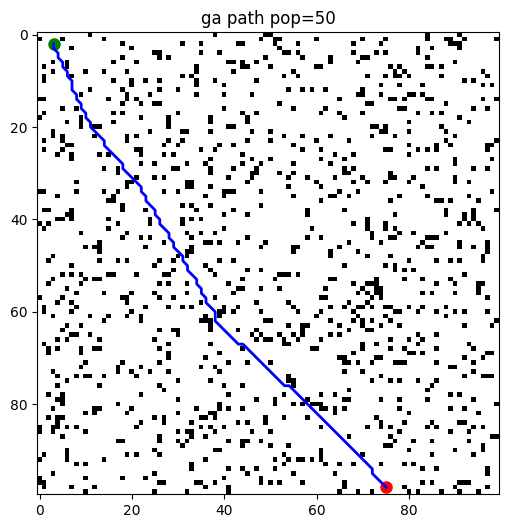

stopping early at generation 181 due to non improvement of fitness.

ga config: {'pop': 100, 'mut': 0.3, 'gen': 200, 'pat': 40, 'wp': 6}
execution time: 5.613403558731079 seconds
best fitness achieved: 129.16557188025854
path length: 101


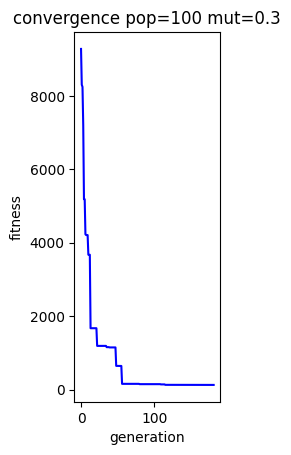

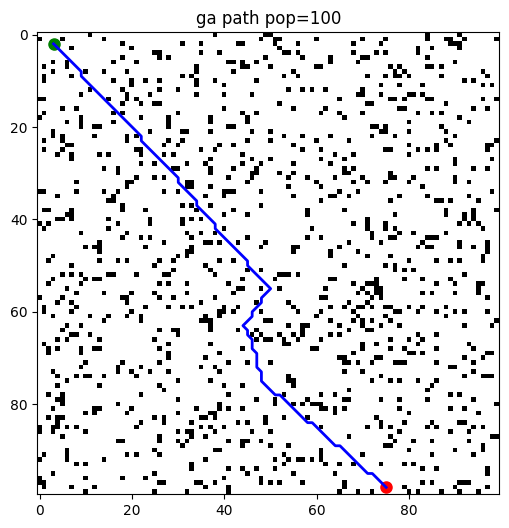

stopping early at generation 112 due to non improvement of fitness.

ga config: {'pop': 200, 'mut': 0.5, 'gen': 200, 'pat': 50, 'wp': 6}
execution time: 5.985621213912964 seconds
best fitness achieved: 1134.8387558301483
path length: 113


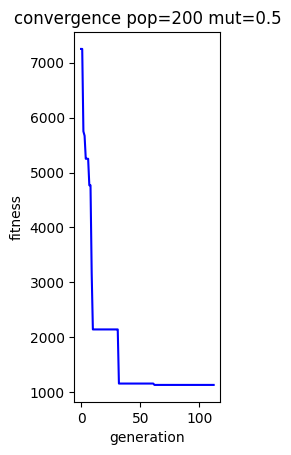

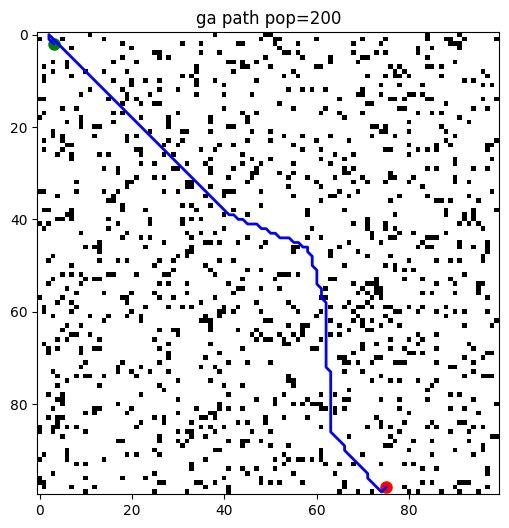

In [1]:
#assignment1-
#import all things-
import numpy as np
import matplotlib.pyplot as plt
import random
import heapq
import time
import math

#step1: data preparation (grid map, obstacles, start, goal)
def create_environment(size, obs_prob):
    grid = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            if random.random() < obs_prob:
                grid[i, j] = 1
    return grid

def plot_environment(grid, start, goal, path=[], title='grid map'):
    plt.figure(figsize=(6, 6))
    plt.imshow(grid, cmap='gray_r')
    plt.plot(start[1], start[0], 'go', markersize=8)
    plt.plot(goal[1], goal[0], 'ro', markersize=8)
    if len(path) > 0:
        y_coords = [p[0] for p in path]
        x_coords = [p[1] for p in path]
        plt.plot(x_coords, y_coords, 'b-', linewidth=2)
    plt.title(title)
    plt.show()

#line interpolation to check continuous path collisions on a grid
def get_line(start, end):
    y0, x0 = start
    y1, x1 = end
    length = int(max(abs(y1 - y0), abs(x1 - x0)))
    if length == 0:
        return [(y0, x0)]
    y_vals = np.round(np.linspace(y0, y1, length + 1)).astype(int)
    x_vals = np.round(np.linspace(x0, x1, length + 1)).astype(int)
    return list(zip(y_vals, x_vals))

#step2:path encoding and baseline solution (a* algorithm)
def get_heuristic(a, b):
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

def run_a_star(grid, start, goal):
    size = len(grid)
    open_set = []
    heapq.heappush(open_set, (0, start))
    came_from = {}
    g_score = {start: 0}
    f_score = {start: get_heuristic(start, goal)}

    while len(open_set) > 0:
        current = heapq.heappop(open_set)[1]
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            path.reverse()
            return path

        for dy, dx in [(0, 1), (0, -1), (1, 0), (-1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1)]:
            ny, nx = current[0] + dy, current[1] + dx
            if 0 <= ny < size and 0 <= nx < size and grid[ny, nx] == 0:
                tentative_g_score = g_score[current] + math.sqrt(dy**2 + dx**2)
                neighbor = (ny, nx)
                if neighbor not in g_score or tentative_g_score < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g_score
                    f_score[neighbor] = tentative_g_score + get_heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))
    return []

#step3:genetic algorithm design
def calculate_fitness(waypoints, grid, start, goal):
    full_path = [start] + waypoints + [goal]
    total_length = 0
    collisions = 0
    size = len(grid)

    for i in range(len(full_path) - 1):
        p1 = full_path[i]
        p2 = full_path[i+1]
        segment = get_line(p1, p2)
        for y, x in segment:
            if 0 <= y < size and 0 <= x < size:
                if grid[y, x] == 1:
                    collisions += 1
            else:
                collisions += 1 #out of bounds counts as collision
        total_length += get_heuristic(p1, p2)

    #objective: minimize length, massive penalty for collisions
    fitness = total_length + (collisions * 500)
    return fitness

def init_population(pop_size, num_waypoints, size):
    pop = []
    for _ in range(pop_size):
        chrom = []
        for _ in range(num_waypoints):
            chrom.append((random.randint(0, size-1), random.randint(0, size-1)))
        pop.append(chrom)
    return pop

def select_parent(pop, fitnesses):
    idx1 = random.randint(0, len(pop)-1)
    idx2 = random.randint(0, len(pop)-1)
    if fitnesses[idx1] < fitnesses[idx2]:
        return pop[idx1]
    return pop[idx2]

def crossover(p1, p2):
    point = random.randint(1, len(p1)-1)
    c1 = p1[:point] + p2[point:]
    c2 = p2[:point] + p1[point:]
    return c1, c2

def mutate(chrom, mut_rate, size):
    new_chrom = []
    #mut_rate must be less than 1. i.e.,   0 to 1 for this function to work.
    for y, x in chrom:
        if random.random() < mut_rate:
            ny = max(0, min(size-1, y + random.randint(-10, 10)))
            nx = max(0, min(size-1, x + random.randint(-10, 10)))
            new_chrom.append((ny, nx))
        else:
            new_chrom.append((y, x))
    return new_chrom

def decode_path(waypoints, start, goal):
    full_path = [start] + waypoints + [goal]
    decoded = []
    for i in range(len(full_path) - 1):
        segment = get_line(full_path[i], full_path[i+1])
        if i > 0:
            segment = segment[1:] #avoid duplicate waypoints
        decoded.extend(segment)
    return decoded

# step 4: ga optimization process
def run_ga(grid, start, goal, pop_size, num_waypoints, generations, mut_rate, patience):
    size = len(grid)
    pop = init_population(pop_size, num_waypoints, size)
    best_fitness = float('inf')
    best_chrom = []
    no_improve = 0
    fitness_history = []

    for gen in range(generations):
        fitnesses = [calculate_fitness(chrom, grid, start, goal) for chrom in pop]
        min_fit = min(fitnesses)
        fitness_history.append(min_fit)

        if min_fit < best_fitness:
            best_fitness = min_fit
            best_chrom = pop[fitnesses.index(min_fit)]
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print('stopping early at generation', gen, 'due to non improvement of fitness.')
            break

        new_pop = []
        new_pop.append(best_chrom) #elitism ::keeps the best 2 of genration
        while len(new_pop) < pop_size:
            p1 = select_parent(pop, fitnesses)
            p2 = select_parent(pop, fitnesses)
            c1, c2 = crossover(p1, p2)
            new_pop.append(mutate(c1, mut_rate, size))
            if len(new_pop) < pop_size:
                new_pop.append(mutate(c2, mut_rate, size))
        pop = new_pop

    best_path = decode_path(best_chrom, start, goal)
    return best_path, fitness_history, best_fitness

# step5:model performance discussion and analysis
def run_analysis():
    size = 100#can be changed to 50 for faster code implementation
    grid = create_environment(size, 0.1)

    #start = (15, 2)
    #goal = (95, 95)
    #input start coordinates
    start_y = int(input("Enter start Y coordinate (0-99): "))
    start_x = int(input("Enter start X coordinate (0-99): "))
    start = (start_y, start_x)

    #input goal coordinates
    goal_y = int(input("Enter goal Y coordinate (0-99): "))
    goal_x = int(input("Enter goal X coordinate (0-99): "))
    goal = (goal_y, goal_x)

    #ensure start and goal are not obstacles
    while grid[start[0], start[1]] == 1:
        start = (random.randint(0, size-1), random.randint(0, size-1))
    while grid[goal[0], goal[1]] == 1:
        goal = (random.randint(0, size-1), random.randint(0, size-1))

    grid[start[0], start[1]] = 0 #ensure start is clear
    grid[goal[0], goal[1]] = 0   #ensure goal is clear, i.e start point and end point dont coincide with the
                                  #randomly genrated obstacles

    print('step1: plotting initial grid. close the window to continue.')
    plot_environment(grid, start, goal, title='initial grid map')

    print('step2: running a* baseline. close the window to continue.')
    t0 = time.time()
    base_path = run_a_star(grid, start, goal)
    t_base = time.time() - t0
    print('baseline a* time:', t_base, 'seconds')
    print('baseline path length:', len(base_path))
    plot_environment(grid, start, goal, base_path, title='baseline a* path')

    print('steps3&4: running ga with multiple hyperparameter configurations.')
    configs = [
        {'pop': 50, 'mut': 0.1, 'gen': 150, 'pat': 30, 'wp': 6},
        {'pop': 100, 'mut': 0.3, 'gen': 200, 'pat': 40, 'wp': 6},

        {'pop': 200, 'mut': 0.5, 'gen': 200, 'pat': 50, 'wp': 6}#,
        # to add other iterations--(remove comment of comma in abovbe line for new iteration) and then put next params
    ]

    plt.figure(figsize=(12, 5))
    for i, config in enumerate(configs):
        t0 = time.time()
        ga_path, history, fit = run_ga(
            grid, start, goal,
            pop_size=config['pop'],
            num_waypoints=config['wp'],
            generations=config['gen'],
            mut_rate=config['mut'],
            patience=config['pat']
        )
        t_ga = time.time() - t0

        print()
        print('ga config:', config)
        print('execution time:', t_ga, 'seconds')
        print('best fitness achieved:', fit)
        print('path length:', len(ga_path))

        #plot convergence
        plt.subplot(1, 3, i+1)
        plt.plot(history, color='blue')
        plt.title('convergence pop=' + str(config['pop']) + ' mut=' + str(config['mut']))
        plt.xlabel('generation')
        plt.ylabel('fitness')

        #plot path
        plot_environment(grid, start, goal, ga_path, title='ga path pop=' + str(config['pop']))

    plt.show()

if __name__ == '__main__':
    run_analysis()
